In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [153]:
# Creating Model Class, inheriting from nn.Module

class Model(nn.Module):
    def __init__(self, in_features = 4, h1 = 8, h2 = 9, out_features = 3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

In [154]:
torch.manual_seed(41)

m1 = Model(4, 8, 9, 3)

In [155]:
import pandas as pd
import matplotlib.pyplot as plt

In [156]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [157]:
my_df["species"] = my_df["species"].replace("setosa", 0)
my_df["species"] = my_df["species"].replace("versicolor", 1)
my_df["species"] = my_df["species"].replace("virginica", 2)
my_df

/var/folders/cj/rxl_zw1j7jz82tt4ktrl_w040000gn/T/ipykernel_24052/1140594182.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df["species"] = my_df["species"].replace("virginica", 2)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [158]:
# Train Test Split Set X, y
X = my_df.drop("species", axis=1)
y = my_df["species"]

In [159]:
# Convert to numpy arrays
X = X.values
y = y.values

In [160]:
from sklearn.model_selection import train_test_split

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 41)

In [162]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [163]:
# Convert X features to long tensors
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [164]:
#set the criterion of the model to measure the error
criterion = nn.CrossEntropyLoss()
# chosen optimiser is Adam, learning rate
optimiser = torch.optim.Adam(m1.parameters(), lr = 0.01)

In [165]:
# Training the model
# *Epoch* is a full run through all the training data
epochs = 100
losses = []

for i in range (epochs):
    #go forward and pass through nn
    y_pred = m1.forward(X_train)

    #Measure the loss
    loss = criterion(y_pred, y_train)
    losses.append(loss.detach().numpy())

    #notify each 10 epochs
    if i % 10 == 0:
        print(f"Epoch number {i} and {loss}")

    #Performing back propagation
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    

Epoch number 0 and 1.1251550912857056
Epoch number 10 and 1.0096259117126465
Epoch number 20 and 0.8157405853271484
Epoch number 30 and 0.585706353187561
Epoch number 40 and 0.3999636471271515
Epoch number 50 and 0.26768797636032104
Epoch number 60 and 0.17942360043525696
Epoch number 70 and 0.12151690572500229
Epoch number 80 and 0.0860118642449379
Epoch number 90 and 0.06520850956439972


Text(0, 0.5, 'Loss')

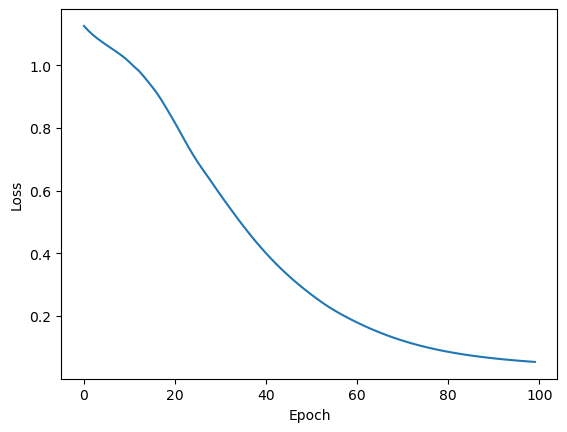

In [166]:
# Graphing loss
plt.plot(range(epochs), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [167]:
# Evaluate Model on Test Dataset
with torch.no_grad(): #turn of backpropagation
    y_eval = m1.forward(X_test) #X_test are feature from our test set,y_eval will be predictions
    loss = criterion(y_eval, y_test)


In [168]:
loss

tensor(0.1315)

In [169]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = m1.forward(data)
        print(f"{i+1}.) {str(y_val)} \t {y_test[i]}")

        #Correct?
        if y_val.argmax().item() == y_test[i]:
            correct += 1
            
print(f"We got {correct}/30 correct")

1.) tensor([-5.8760,  4.4628,  6.5124]) 	 2
2.) tensor([-7.5436,  4.1670,  9.7255]) 	 2
3.) tensor([-8.4504,  5.1271, 10.1987]) 	 2
4.) tensor([-4.3398,  5.6267,  2.5608]) 	 1
5.) tensor([-7.1825,  4.8754,  8.2992]) 	 2
6.) tensor([-3.3974,  5.3463,  1.2803]) 	 1
7.) tensor([-5.9230,  4.9822,  5.9997]) 	 2
8.) tensor([-4.2881,  5.7003,  2.3889]) 	 1
9.) tensor([-6.5356,  4.9257,  7.1260]) 	 2
10.) tensor([-8.0509,  4.4129, 10.3286]) 	 2
11.) tensor([-5.6762,  4.9500,  5.6215]) 	 2
12.) tensor([ 4.5662, -2.2476, -2.8911]) 	 0
13.) tensor([ 4.2571, -1.9967, -2.7330]) 	 0
14.) tensor([-2.1108,  4.0515,  0.5799]) 	 1
15.) tensor([ 3.4575, -1.2098, -2.3514]) 	 0
16.) tensor([-5.4724,  5.1165,  5.0934]) 	 2
17.) tensor([ 4.0557, -1.7949, -2.6492]) 	 0
18.) tensor([-5.8075,  4.6053,  6.2458]) 	 1
19.) tensor([ 4.4343, -2.1392, -2.8242]) 	 0
20.) tensor([ 3.4528, -1.2514, -2.3660]) 	 0
21.) tensor([-2.6189,  4.5619,  0.8574]) 	 1
22.) tensor([-7.7412,  4.7377,  9.4198]) 	 2
23.) tensor([ 3.574

# Evaluating A New Flower

In [185]:
# stereotypical setosa:
new_flower = torch.tensor([5.0, 3.5, 1.5, 0.2])

In [186]:
with torch.no_grad():
    print(m1(new_flower))

tensor([ 4.6226, -2.3041, -2.9145])


# Saving and Loading a Model

In [197]:
#saving
torch.save(m1.state_dict(), "my_first_model.pt")

In [198]:
#loading
new_model = Model()
new_model.load_state_dict(torch.load("my_first_model.pt"))

<All keys matched successfully>

In [199]:
# Ensure correct loading
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)

In [200]:
# Testing the loaded model
newer_flower = torch.tensor([5.5, 3.0, 4.5, 1.7])
with torch.no_grad():
    print(m1(newer_flower))

tensor([-4.9046,  4.7518,  4.5152])
